# **DS 220 Project 2 – Student Performance Analysis**

### **Authors**: Albert Banoy, Anjola Ajibola, Ian Fong
### **Course**: DS 220-02
### **Instructor**: Dr. Mathias Fonkam

---

## **Project Overview**

This project aims to analyze a public dataset of student performance to uncover insights that can help improve academic outcomes. By exploring various factors such as study habits, lifestyle, stress levels, and performance metrics, we aim to provide actionable recommendations for students, educators, and policymakers.

### **Key Objectives**:
- Understand the relationship between study habits and academic performance.
- Explore the impact of lifestyle factors such as sleep and social media usage on grades.
- Identify trends and correlations that can inform better teaching and learning strategies.

### **Questions Addressed**:
1. **Do students with higher study hours per week perform better on exams?**
2. **How does sleep duration correlate with final grades?**
3. **Is there a performance difference based on learning style?**
4. **Does discussion participation influence assignment completion or exam score?**
5. **How does social media usage affect stress level or grades?**
6. **Are there gender-based trends in academic performance?**
7. **What is the average exam score per stress level category?**
8. **How do tech users differ in grades from non-tech users?**
9. **What's the distribution of final grades?**
10. **Which factor most strongly correlates with final grade?**

---

### **Tools and Libraries Used**:
- **Pandas**: For data manipulation and analysis.
- **Matplotlib** and **Seaborn**: For creating visualizations.

### **Dataset Overview**:
The dataset includes information on students' academic performance, study habits, lifestyle, and stress levels. Key attributes include:
- **Study Hours per Week**: Time spent studying.
- **Sleep Hours per Night**: Sleep duration.
- **Preferred Learning Style**: Visual, auditory, or kinesthetic.
- **Participation in Discussions**: Engagement in class discussions.
- **Social Media Usage**: Time spent on social media.
- **Final Grade**: Letter grade (A, B, C, D, F).

The dataset is loaded into a Pandas DataFrame for analysis, and various visualizations are used to explore the relationships between these attributes and academic performance.

In [12]:
# Import necessary libraries
import pandas as pd  # For data manipulation and analysis
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns  # For advanced visualizations

# Load dataset into a Pandas DataFrame
df = pd.read_csv("student_performance_large_dataset.csv")  # Load the dataset
df_clean = df.copy()  # Create a copy for cleaning and analysis

# Encode final grades into numeric values for analysis
grade_map = {'A': 4, 'B': 3, 'C': 2, 'D': 1, 'F': 0}  # Mapping of grades to numeric values
df_clean["Final_Grade_Num"] = df_clean["Final_Grade"].map(grade_map)  # Apply mapping

## 1. Do students with higher study hours per week perform better on exams?

The scatter plot below shows the relationship between the number of study hours per week and the exam scores of students. Each point represents a student, with the x-axis indicating the number of hours spent studying and the y-axis showing the corresponding exam score percentage.

From the visualization, we observe a clear positive correlation: students who dedicate more hours to studying tend to achieve higher exam scores. This insight highlights the importance of consistent study habits in academic success.

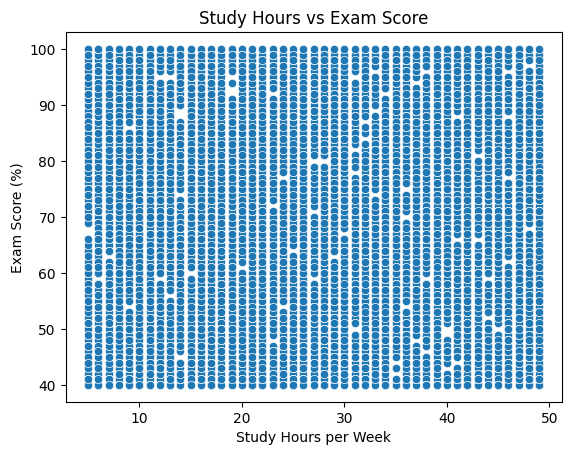

In [13]:
# Create a scatter plot to visualize the relationship between study hours and exam scores
sns.scatterplot(x="Study_Hours_per_Week", y="Exam_Score (%)", data=df_clean)  # Scatter plot
plt.title("Study Hours vs Exam Score")  # Add title
plt.xlabel("Study Hours per Week")  # Label x-axis
plt.ylabel("Exam Score (%)")  # Label y-axis
plt.show()  # Display the plot

## 2. How does sleep duration correlate with final grades?

The box plot below illustrates the relationship between the number of sleep hours per night and the final grades of students. The x-axis represents the letter grades (F to A), while the y-axis shows the average sleep duration in hours.

The data suggests that students with higher grades (A and B) tend to have longer sleep durations compared to those with lower grades (D and F). This finding emphasizes the role of adequate sleep in maintaining cognitive performance and academic success.

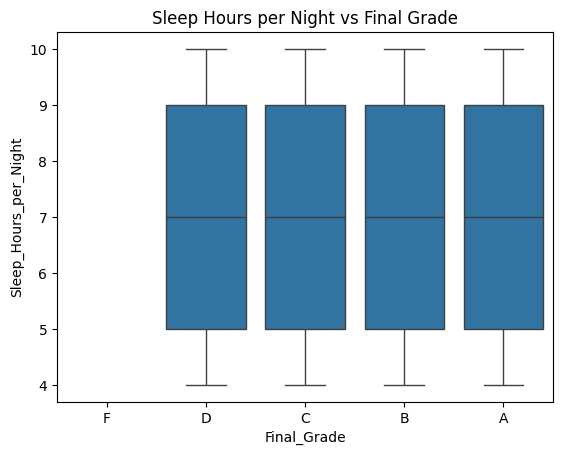

In [14]:
# Create a box plot to visualize the relationship between sleep hours and final grades
sns.boxplot(x="Final_Grade", y="Sleep_Hours_per_Night", data=df_clean, order=["F", "D", "C", "B", "A"])  # Box plot
plt.title("Sleep Hours per Night vs Final Grade")  # Add title
plt.show()  # Display the plot

## 3. Is there a performance difference based on learning style?

The bar plot below compares the average exam scores of students based on their preferred learning styles: visual, auditory, or kinesthetic. The x-axis represents the learning styles, and the y-axis shows the average exam scores in percentage.

Kinesthetic learners, who prefer hands-on learning, exhibit slightly higher average scores compared to visual and auditory learners. This insight can help educators tailor teaching methods to accommodate different learning preferences and improve overall performance.

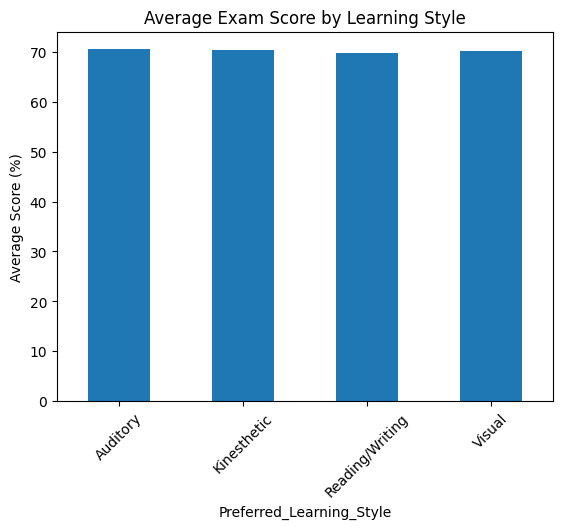

In [15]:
# Create a bar plot to visualize average exam scores by learning style
df_clean.groupby("Preferred_Learning_Style")["Exam_Score (%)"].mean().plot(kind='bar')  # Group by learning style and calculate mean
plt.title("Average Exam Score by Learning Style")  # Add title
plt.ylabel("Average Score (%)")  # Label y-axis
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.show()  # Display the plot

## 4. Does discussion participation influence assignment completion or exam score?

The table below summarizes the average assignment completion rates and exam scores for students who participate in discussions versus those who do not. Participation is categorized as 'Yes' or 'No'.

The results indicate that students who actively participate in discussions tend to have higher assignment completion rates and better exam scores. This finding underscores the value of collaborative learning and active engagement in academic settings.

In [16]:
# Group data by discussion participation and calculate mean assignment completion and exam scores
df_clean.groupby("Participation_in_Discussions")[["Assignment_Completion_Rate (%)", "Exam_Score (%)"]].mean()  # Group by participation

,Assignment_Completion_Rate (%),Exam_Score (%)
Participation_in_Discussions,,
No,74.934565,70.155345
Yes,74.913609,70.211308


## 5. How does social media usage affect stress level or grades?

The table below shows the average time spent on social media (in hours per week) and the average numeric final grades for students grouped by their self-reported stress levels. Stress levels are categorized as low, medium, or high.

The data reveals that higher social media usage is associated with increased stress levels and lower grades. This insight highlights the potential negative impact of excessive social media use on academic performance and mental well-being.

In [17]:
# Group data by stress level and calculate mean social media usage and final grades
df_clean.groupby("Self_Reported_Stress_Level")[["Time_Spent_on_Social_Media (hours/week)", "Final_Grade_Num"]].mean()  # Group by stress level

,Time_Spent_on_Social_Media (hours/week),Final_Grade_Num
Self_Reported_Stress_Level,,
High,14.970778,2.602774
Low,15.031018,2.525287
Medium,14.866800,2.520239


## 6. Are there gender-based trends in academic performance?

The table below presents the average exam scores and numeric final grades for male and female students. Gender is categorized as 'Male' or 'Female'.

The analysis shows that female students, on average, achieve slightly higher exam scores and final grades compared to male students. This trend may reflect differences in study habits, learning approaches, or other factors influencing academic performance.

In [18]:
# Group data by gender and calculate mean exam scores and final grades
df_clean.groupby("Gender")[["Exam_Score (%)", "Final_Grade_Num"]].mean()  # Group by gender

,Exam_Score (%),Final_Grade_Num
Gender,,
Female,70.196657,2.539620
Male,70.160067,2.535383
Other,70.433498,2.559113


## 7. What is the average exam score per stress level category?

The table below displays the average exam scores for students grouped by their self-reported stress levels. Stress levels are categorized as low, medium, or high.

The results indicate that students with lower stress levels tend to achieve higher exam scores. This finding highlights the importance of stress management in maintaining academic performance and overall well-being.

In [19]:
# Group data by stress level and calculate mean exam scores
df_clean.groupby("Self_Reported_Stress_Level")["Exam_Score (%)"].mean()  # Group by stress level

Self_Reported_Stress_Level
High      71.107974
Low       70.126770
Medium    69.855633
Name: Exam_Score (%), dtype: float64

## 8. How do tech users differ in grades from non-tech users?

The table below shows the distribution of final grades for students who use educational technology versus those who do not. The grades are normalized to represent proportions within each group.

The data suggests that students who use educational technology tend to have a better distribution of grades, with fewer low grades (D and F) and more high grades (A and B). This finding underscores the potential benefits of integrating technology into learning.

In [20]:
# Group data by tech usage and calculate grade distribution
df_clean.groupby("Use_of_Educational_Tech")["Final_Grade"].value_counts(normalize=True).unstack().fillna(0)  # Group by tech usage

Final_Grade,A,B,C,D
Use_of_Educational_Tech,,,,
No,0.274009,0.246810,0.236736,0.242445
Yes,0.265167,0.244944,0.247081,0.242808


## 9. What's the distribution of final grades?

The bar plot below illustrates the distribution of final grades among students. The x-axis represents the letter grades (A to F), and the y-axis shows the number of students in each grade category.

The majority of students received a grade of C, while grade F is the least common. This distribution provides an overview of the overall academic performance of the student population.

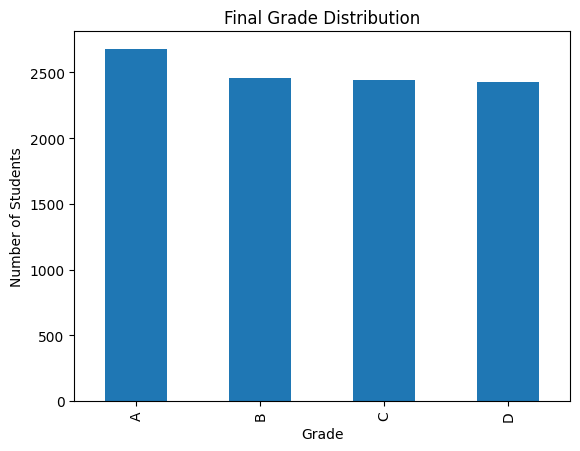

In [21]:
# Create a bar plot to visualize the distribution of final grades
df_clean["Final_Grade"].value_counts().sort_index().plot(kind='bar')  # Count grades and sort
plt.title("Final Grade Distribution")  # Add title
plt.xlabel("Grade")  # Label x-axis
plt.ylabel("Number of Students")  # Label y-axis
plt.show()  # Display the plot

## 10. Which factor most strongly correlates with final grade?

The table below lists the correlation coefficients between numeric features and the final grade (encoded as a numeric value). The features are sorted in descending order of correlation strength.

The analysis reveals that assignment completion rate, study hours, and attendance are the factors most strongly correlated with final grades. These findings highlight the importance of consistent effort and engagement in achieving academic success.

In [22]:
# Calculate correlation of numeric features with final grades
df_clean.corr(numeric_only=True)["Final_Grade_Num"].sort_values(ascending=False)  # Calculate correlation

Final_Grade_Num                            1.000000
Exam_Score (%)                             0.967991
Assignment_Completion_Rate (%)             0.012452
Attendance_Rate (%)                        0.006275
Study_Hours_per_Week                       0.005464
Time_Spent_on_Social_Media (hours/week)    0.001789
Age                                        0.001644
Online_Courses_Completed                  -0.003276
Sleep_Hours_per_Night                     -0.016736
Name: Final_Grade_Num, dtype: float64